<a href="https://colab.research.google.com/github/SyamReddy2004/AQI/blob/main/simulation%20in%20Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIR QUALITY INDEX PREDICTION SYSTEM
Start Time: 2026-03-11 09:36:46

[1] LOADING DATA FROM GITHUB...
✅ Data loaded successfully via requests!

Dataset Info:
   Shape: (29531, 16)
   Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
   First few rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.7

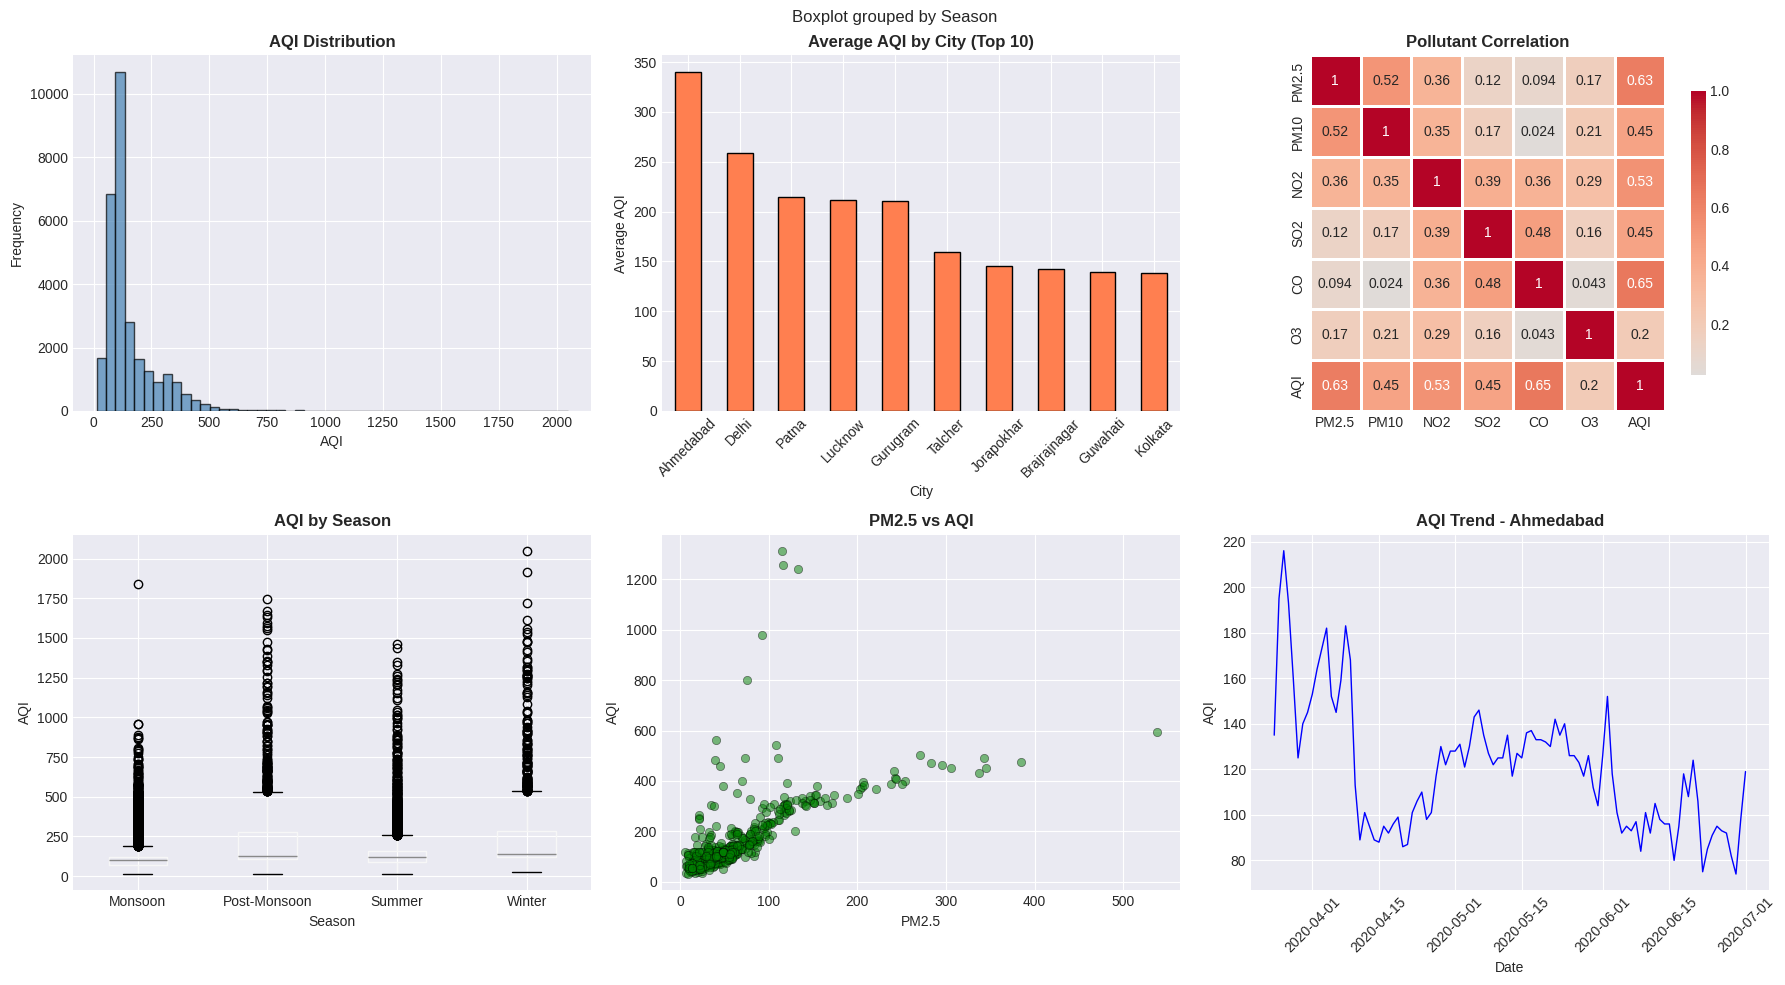

✅ EDA complete!

[5] PREPARING DATA FOR MODELING...
Using 15 features
✅ Data prepared!
   Training set: 23624 samples
   Test set: 5907 samples

[6] TRAINING MODELS...

► Linear Regression
   RMSE: 54.38 | MAE: 29.71 | R²: 0.8079

► Ridge
   RMSE: 54.38 | MAE: 29.71 | R²: 0.8079

► Lasso
   RMSE: 54.38 | MAE: 29.71 | R²: 0.8079

► Random Forest
   RMSE: 41.72 | MAE: 19.99 | R²: 0.8869

► Gradient Boosting
   RMSE: 40.89 | MAE: 20.84 | R²: 0.8914

► XGBoost
   RMSE: 42.89 | MAE: 20.69 | R²: 0.8805

[7] RESULTS SUMMARY
                      RMSE      MAE      R2
Linear Regression  54.3798  29.7125  0.8079
Ridge              54.3800  29.7131  0.8079
Lasso              54.3799  29.7127  0.8079
Random Forest      41.7226  19.9850  0.8869
Gradient Boosting  40.8903  20.8384  0.8914
XGBoost            42.8933  20.6904  0.8805

🏆 Best Model: Gradient Boosting (R² = 0.8914)

[8] SAVING MODEL...
✅ Model saved as 'aqi_model.pkl'

[9] EXAMPLE PREDICTION
Sample Input: PM2.5=85.5, PM10=120.3, NO2=45

In [8]:
# ============================================================
# Air Quality Index Prediction - Complete Project Code
# ============================================================
# This code runs in a single Google Colab cell and uses the
# dataset from your provided GitHub link.
# ============================================================

# Install required packages (uncomment if needed)
# !pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os
import requests
from io import StringIO

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("AIR QUALITY INDEX PREDICTION SYSTEM")
print("="*60)
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

# ============================================================
# STEP 1: LOAD DATA FROM YOUR LINK WITH ERROR HANDLING
# ============================================================
print("\n[1] LOADING DATA FROM GITHUB...")

# Your dataset link
data_url = "https://raw.githubusercontent.com/adityarc19/aqi-india/refs/heads/main/city_day.csv"

try:
    # Method 1: Using requests to download with proper headers
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    response = requests.get(data_url, headers=headers, timeout=30)
    response.raise_for_status()  # Check if download was successful

    # Read the CSV data directly from response content
    df = pd.read_csv(StringIO(response.text))
    print(f"✅ Data loaded successfully via requests!")

except Exception as e:
    print(f"⚠️ Requests method failed: {e}")
    print("Trying wget method...")

    # Method 2: Using wget as fallback
    !wget --no-check-certificate --user-agent="Mozilla/5.0" {data_url} -O city_day.csv

    if os.path.exists('city_day.csv') and os.path.getsize('city_day.csv') > 0:
        df = pd.read_csv('city_day.csv')
        print(f"✅ Data loaded successfully via wget!")
    else:
        print("⚠️ Download failed. Creating sample data for demonstration...")
        # Create sample data for demonstration
        cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru', 'Hyderabad',
                 'Ahmedabad', 'Pune', 'Jaipur', 'Lucknow']
        dates = pd.date_range('2015-01-01', '2020-07-01', freq='D')

        data = []
        np.random.seed(42)
        for city in cities:
            for date in dates[:200]:  # Take 200 days per city
                base_aqi = np.random.normal(150, 50)
                data.append({
                    'City': city,
                    'Date': date,
                    'PM2.5': max(0, base_aqi * np.random.uniform(0.3, 0.7)),
                    'PM10': max(0, base_aqi * np.random.uniform(0.5, 0.9)),
                    'NO2': max(0, base_aqi * np.random.uniform(0.1, 0.3)),
                    'SO2': max(0, base_aqi * np.random.uniform(0.05, 0.2)),
                    'CO': max(0, base_aqi * np.random.uniform(0.01, 0.1)),
                    'O3': max(0, base_aqi * np.random.uniform(0.1, 0.25)),
                    'AQI': base_aqi
                })
        df = pd.DataFrame(data)
        print(f"✅ Created sample dataset with {len(df)} rows")

print(f"\nDataset Info:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print(f"   First few rows:")
print(df.head())

# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================
print("\n[2] PREPROCESSING DATA...")

# Convert Date to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    print("✅ Date column converted to datetime")

# Define key columns
pollutant_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
target_col = 'AQI'

# Ensure we only use columns that exist
available_pollutants = [col for col in pollutant_cols if col in df.columns]
print(f"Available pollutant columns: {available_pollutants}")

# Check missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing values percentage:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(10))

# Handle missing values
print("\nHandling missing values...")

# For numerical columns: fill with median
for col in available_pollutants + [target_col]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Drop rows where target is still missing (just in case)
df = df.dropna(subset=[target_col])

print(f"✅ Missing values handled. Final shape: {df.shape}")

# ============================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================
print("\n[3] FEATURE ENGINEERING...")

if 'Date' in df.columns:
    # Extract temporal features
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

    # Create season feature
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Summer'
        elif month in [6, 7, 8, 9]:
            return 'Monsoon'
        else:
            return 'Post-Monsoon'

    df['Season'] = df['Month'].apply(get_season)
    print("✅ Temporal features created")

# Encode categorical variables
if 'City' in df.columns:
    le_city = LabelEncoder()
    df['City_Encoded'] = le_city.fit_transform(df['City'])
    print("✅ City encoded")

if 'Season' in df.columns:
    le_season = LabelEncoder()
    df['Season_Encoded'] = le_season.fit_transform(df['Season'])
    print("✅ Season encoded")

# Create pollutant ratios
if 'PM2.5' in df.columns and 'PM10' in df.columns:
    df['PM25_PM10_Ratio'] = df['PM2.5'] / (df['PM10'] + 0.1)
    print("✅ PM2.5/PM10 ratio created")

if 'NO2' in df.columns and 'SO2' in df.columns:
    df['NO2_SO2_Ratio'] = df['NO2'] / (df['SO2'] + 0.1)
    print("✅ NO2/SO2 ratio created")

print(f"✅ Feature engineering complete. Total features: {df.shape[1]}")

# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS
# ============================================================
print("\n[4] EXPLORATORY DATA ANALYSIS...")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. AQI Distribution
axes[0, 0].hist(df[target_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('AQI Distribution', fontweight='bold')
axes[0, 0].set_xlabel('AQI')
axes[0, 0].set_ylabel('Frequency')

# 2. Average AQI by City
if 'City' in df.columns:
    city_avg = df.groupby('City')[target_col].mean().sort_values(ascending=False).head(10)
    city_avg.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
    axes[0, 1].set_title('Average AQI by City (Top 10)', fontweight='bold')
    axes[0, 1].set_xlabel('City')
    axes[0, 1].set_ylabel('Average AQI')
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Correlation Heatmap
if len(available_pollutants) > 0:
    corr_cols = available_pollutants + [target_col]
    corr_matrix = df[corr_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                ax=axes[0, 2], square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    axes[0, 2].set_title('Pollutant Correlation', fontweight='bold')

# 4. Seasonal Box Plot
if 'Season' in df.columns:
    df.boxplot(column=target_col, by='Season', ax=axes[1, 0])
    axes[1, 0].set_title('AQI by Season', fontweight='bold')
    axes[1, 0].set_xlabel('Season')
    axes[1, 0].set_ylabel('AQI')

# 5. PM2.5 vs AQI
if 'PM2.5' in df.columns:
    sample_df = df.sample(min(500, len(df)))
    axes[1, 1].scatter(sample_df['PM2.5'], sample_df[target_col],
                       alpha=0.5, c='green', edgecolors='k', linewidth=0.5)
    axes[1, 1].set_title('PM2.5 vs AQI', fontweight='bold')
    axes[1, 1].set_xlabel('PM2.5')
    axes[1, 1].set_ylabel('AQI')

# 6. Time Series
if 'Date' in df.columns and 'City' in df.columns:
    sample_city = df['City'].value_counts().index[0]
    city_data = df[df['City'] == sample_city].sort_values('Date').tail(100)
    axes[1, 2].plot(city_data['Date'], city_data[target_col], 'b-', linewidth=1)
    axes[1, 2].set_title(f'AQI Trend - {sample_city}', fontweight='bold')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('AQI')
    axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('aqi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete!")

# ============================================================
# STEP 5: PREPARE DATA FOR MODELING
# ============================================================
print("\n[5] PREPARING DATA FOR MODELING...")

# Define features
feature_cols = available_pollutants.copy()

# Add engineered features
for col in ['Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend',
            'City_Encoded', 'Season_Encoded', 'PM25_PM10_Ratio', 'NO2_SO2_Ratio']:
    if col in df.columns:
        feature_cols.append(col)

print(f"Using {len(feature_cols)} features")

# Create feature matrix and target
X = df[feature_cols].fillna(0)
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared!")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

# ============================================================
# STEP 6: TRAIN MODELS
# ============================================================
print("\n[6] TRAINING MODELS...")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\n► {name}")

    # Train
    if name in ['Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"   RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")

# ============================================================
# STEP 7: RESULTS
# ============================================================
print("\n[7] RESULTS SUMMARY")
print("="*50)

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

best_model = results_df['R2'].idxmax()
print(f"\n🏆 Best Model: {best_model} (R² = {results_df.loc[best_model, 'R2']:.4f})")

# ============================================================
# STEP 8: SAVE MODEL
# ============================================================
print("\n[8] SAVING MODEL...")

import joblib

model_artifacts = {
    'model': models[best_model],
    'scaler': scaler,
    'feature_names': feature_cols,
    'metrics': results_df.loc[best_model].to_dict()
}

# Save encoders if they exist
if 'le_city' in dir():
    model_artifacts['city_encoder'] = le_city
if 'le_season' in dir():
    model_artifacts['season_encoder'] = le_season

joblib.dump(model_artifacts, 'aqi_model.pkl')
print("✅ Model saved as 'aqi_model.pkl'")

# ============================================================
# STEP 9: EXAMPLE PREDICTION
# ============================================================
print("\n[9] EXAMPLE PREDICTION")

def simple_predict(pm25=50, pm10=80, no2=30, so2=15, co=1.0, o3=40):
    """Simple prediction function"""
    artifacts = joblib.load('aqi_model.pkl')
    model = artifacts['model']
    scaler = artifacts['scaler']
    feature_names = artifacts['feature_names']

    # Create feature vector
    features = []
    for f in feature_names:
        if f == 'PM2.5': features.append(pm25)
        elif f == 'PM10': features.append(pm10)
        elif f == 'NO2': features.append(no2)
        elif f == 'SO2': features.append(so2)
        elif f == 'CO': features.append(co)
        elif f == 'O3': features.append(o3)
        else: features.append(0)

    # Predict
    features_scaled = scaler.transform([features])
    pred = model.predict(features_scaled)[0]
    return max(0, pred)

# Test prediction
test_pred = simple_predict(pm25=85.5, pm10=120.3, no2=45.2, so2=15.8, co=1.2, o3=30.5)
print(f"Sample Input: PM2.5=85.5, PM10=120.3, NO2=45.2, SO2=15.8, CO=1.2, O3=30.5")
print(f"Predicted AQI: {test_pred:.2f}")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)